# Parity Hparam Sweep — LR and WD
G=6, DiT-mini. Plots:
1. Training traces (loss, sample acc, group acc, mem ratio, grad norm)
2. Summary bar charts (peak acc, end acc, step→80%, step→1% mem, end mem)

In [4]:
%load_ext autoreload
%autoreload 2

In [58]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from circuit_toolkit.plot_utils import saveallforms
import matplotlib
sys.path.insert(0, os.path.dirname(os.getcwd()))

matplotlib.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype':  42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size': 11,
})
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os

SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
FIGDIR   = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/DiT_GPT_lr_wd_sweep"
os.makedirs(FIGDIR, exist_ok=True)

In [6]:
# ── Experiment lists ──────────────────────────────────────────────────────────
lr_exps = [
    'DiT_mini_parity_N4096_D36_G6_even_lr1e5',
    'DiT_mini_parity_N4096_D36_G6_even_lr3e5',
    'DiT_mini_parity_N4096_D36_G6_even_lr1e4',
    'DiT_mini_parity_N4096_D36_G6_even_lr3e4',
    'DiT_mini_parity_N4096_D36_G6_even_lr1e3',
    'DiT_mini_parity_N4096_D36_G6_even_lr3e3',
]
lr_labels = ['lr=1e-5','lr=3e-5','lr=1e-4','lr=3e-4','lr=1e-3','lr=3e-3']
lr_colors = plt.cm.plasma(np.linspace(0.05, 0.85, len(lr_exps)))

wd_exps = [
    'DiT_mini_parity_N4096_D36_G6_even_wd1e6',
    'DiT_mini_parity_N4096_D36_G6_even_wd1e5',
    'DiT_mini_parity_N4096_D36_G6_even_wd1e4',
    'DiT_mini_parity_N4096_D36_G6_even_wd1e3',
    'DiT_mini_parity_N4096_D36_G6_even_wd1e2',
    'DiT_mini_parity_N4096_D36_G6_even_wd5e2',
]
wd_labels = ['wd=1e-6','wd=1e-5','wd=1e-4','wd=1e-3','wd=1e-2','wd=5e-2']
wd_colors = plt.cm.viridis(np.linspace(0.05, 0.85, len(wd_exps)))

TAGS = [
    ('Training/Loss',          'Loss'),
    ('Eval/Sample_Accuracy',   'Sample Accuracy'),
    ('Eval/PerGroup_Accuracy', 'Group Accuracy'),
    ('Eval/Sample_Mem_Ratio',  'Sample Mem Ratio'),
    ('Eval/GradNorm',          'Grad Norm'),
]

In [22]:
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
from core.onset_lib import load_eval_timeseries, load_eval_dataframe, load_args, first_sustained_crossing

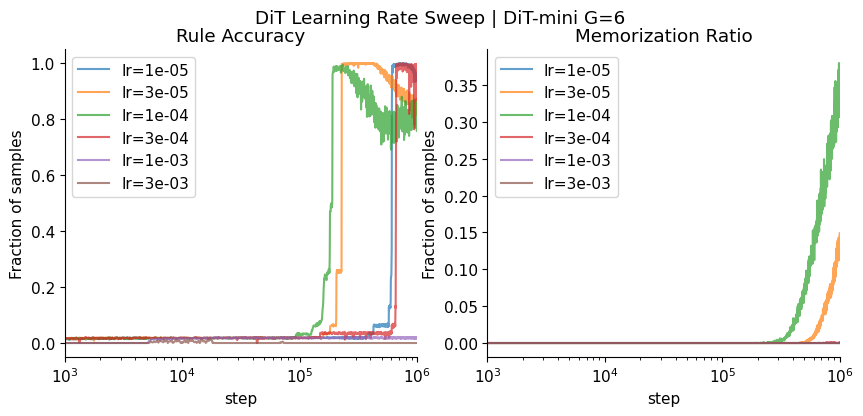

In [71]:
figh, axs = plt.subplots(1, 2, figsize=(10, 4))
for expname in lr_exps:
    tb_traces = load_eval_dataframe(expname, SAVEROOT)
    args = load_args(expname, SAVEROOT)
    lr = args.get("lr")
    sns.lineplot(data=tb_traces, x='step', y='valid_acc', label=f'lr={lr:.0e}', ax=axs[0], alpha=0.7)  
    sns.lineplot(data=tb_traces, x='step', y='mem_ratio', label=f'lr={lr:.0e}', ax=axs[1], alpha=0.7)  
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].set_title('Rule Accuracy')
axs[1].set_title('Memorization Ratio')
axs[0].set_ylabel('Fraction of samples')
axs[1].set_ylabel('Fraction of samples')
axs[0].legend()
axs[0].set_xlim(1E3, 1e6)
axs[1].set_xlim(1E3, 1e6)
# axs[1].legend()
plt.suptitle('DiT Learning Rate Sweep | DiT-mini G=6')
saveallforms(FIGDIR, 'DiT_mini_G6_learning_curves_lr_sweep', figh)
plt.show()


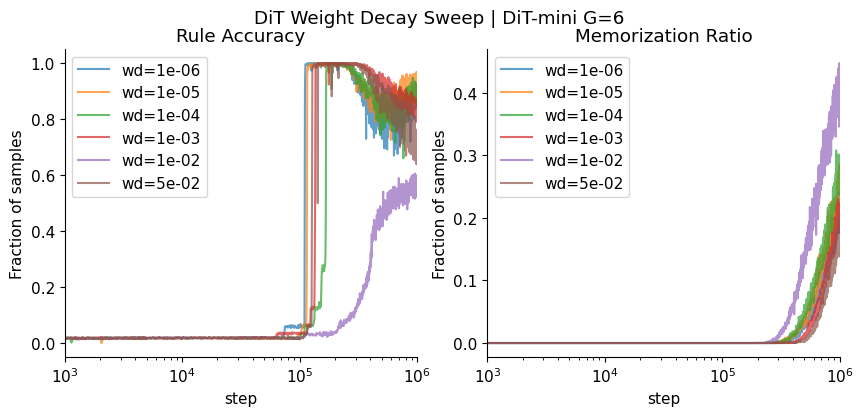

In [70]:
figh, axs = plt.subplots(1, 2, figsize=(10, 4))
for expname in wd_exps:
    tb_traces = load_eval_dataframe(expname, SAVEROOT)
    args = load_args(expname, SAVEROOT)
    wd = args.get("weight_decay")
    sns.lineplot(data=tb_traces, x='step', y='valid_acc', label=f'wd={wd:.0e}', ax=axs[0], alpha=0.7)  
    sns.lineplot(data=tb_traces, x='step', y='mem_ratio', label=f'wd={wd:.0e}', ax=axs[1], alpha=0.7)  
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].set_title('Rule Accuracy')
axs[1].set_title('Memorization Ratio')
axs[0].set_ylabel('Fraction of samples')
axs[1].set_ylabel('Fraction of samples')
axs[0].legend()
axs[0].set_xlim(1E3, 1e6)
axs[1].set_xlim(1E3, 1e6)
# axs[1].legend()
plt.suptitle('DiT Weight Decay Sweep | DiT-mini G=6')
saveallforms(FIGDIR, 'DiT_mini_G6_learning_curves_wd_sweep', figh)
plt.show()

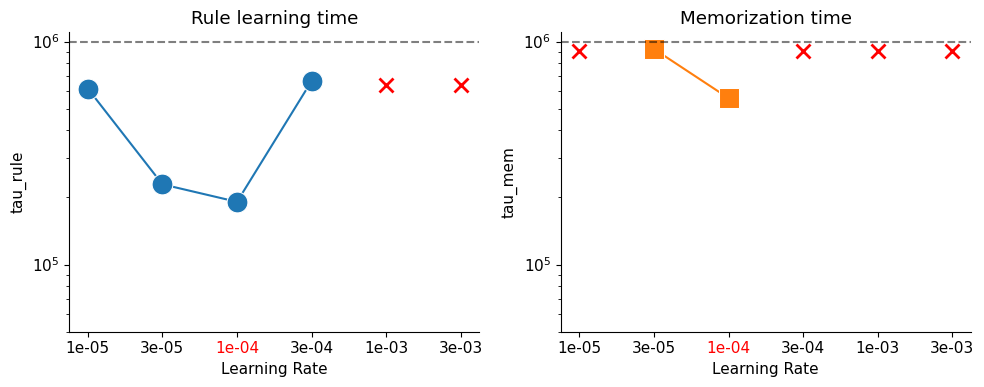

In [ ]:
# Compute tau_rule and tau_mem as before, but always show all lr_labels, even if value is missing
def mark_cross_on_ax(ax, x_positions, y_values):
    """Add red crosses at bars where y is 0 or nan"""
    for i, y in enumerate(y_values):
        if (y == 0) or (np.isnan(y)):
            # Place the cross at 90% up the current y-limits (relative fraction)
            ylim = ax.get_ylim()
            frac = 0.9  # cross at 90% up
            y_frac = ylim[0] + (ylim[1] - ylim[0]) * frac
            ax.plot(i, y_frac, marker='x', color='red', markersize=10, markeredgewidth=2, zorder=10)
     
     
tau_rule_list = []
tau_mem_list = []
lr_list = []
for expname in lr_exps:
    tb_traces = load_eval_dataframe(expname, SAVEROOT)
    args = load_args(expname, SAVEROOT)
    lr = args.get("lr")
    # Compute tau_rule and tau_mem; if trace missing, mark as nan
    tau_rule = first_sustained_crossing(tb_traces['step'], tb_traces['valid_acc'], 0.90)
    tau_mem  = first_sustained_crossing(tb_traces['step'], tb_traces['mem_ratio'], 0.1)
    lr_list.append(lr)
    tau_rule_list.append(tau_rule)# if ~np.isnan(tau_rule) else 0)
    tau_mem_list.append(tau_mem)# if ~np.isnan(tau_mem) else 0)
df_lr_list = pd.DataFrame({'lr': lr_list, 'tau_rule': tau_rule_list, 'tau_mem': tau_mem_list})

import matplotlib.pyplot as plt

# Assume df_lr_list exists from above with columns 'lr', 'tau_rule', 'tau_mem'
# Plot: categorical x = 'lr', bar height = 'tau_rule' and 'tau_mem'
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
# Cast lr to string for categorical axis
x_labels = [f"{lr:.0e}" for lr in df_lr_list['lr']]
sns.lineplot(x=x_labels, y=df_lr_list['tau_rule'], ax=axs[0], marker='o', markersize=15, color='tab:blue')
sns.lineplot(x=x_labels, y=df_lr_list['tau_mem'], ax=axs[1], marker='s', markersize=15, color='tab:orange')
# Add red crosses where value is 0 or nan
mark_cross_on_ax(axs[0], x_labels, df_lr_list['tau_rule'])
mark_cross_on_ax(axs[1], x_labels, df_lr_list['tau_mem'])

axs[0].set_title('Rule learning time')
axs[1].set_title('Memorization time')
axs[0].set_xlabel('Learning Rate')
axs[1].set_xlabel('Learning Rate')
axs[0].set_ylabel('tau_rule')
axs[1].set_ylabel('tau_mem')
for ax in axs:
    ax.set_yscale('log')
    ax.set_ylim(5e4, 1.1e6)
    ax.axhline(1e6, color='k', linestyle='--', alpha=0.5)
# --- Color the xlabel 1E-04 in red (main exp) ---
# Find which xtick label is 1e-4 (in scientific: 1E-04, which is f"{1e-4:.0e}" == '1e-04' or '1E-04')
for ax in axs:
    for label in ax.get_xticklabels():
        # Label text can be upper or lower case; handle both
        if label.get_text().lower() == '1e-04' or label.get_text().upper() == '1E-04':
            label.set_color('red')
        # Also, sometimes matplotlib may use e-4 for small values, check for both (in case)
        if label.get_text() in ['1e-04', '1E-04']:
            label.set_color('red')

plt.tight_layout()
saveallforms(FIGDIR, 'DiT_mini_G6_tau_rule_mem_lr_sweep', fig)
plt.show()

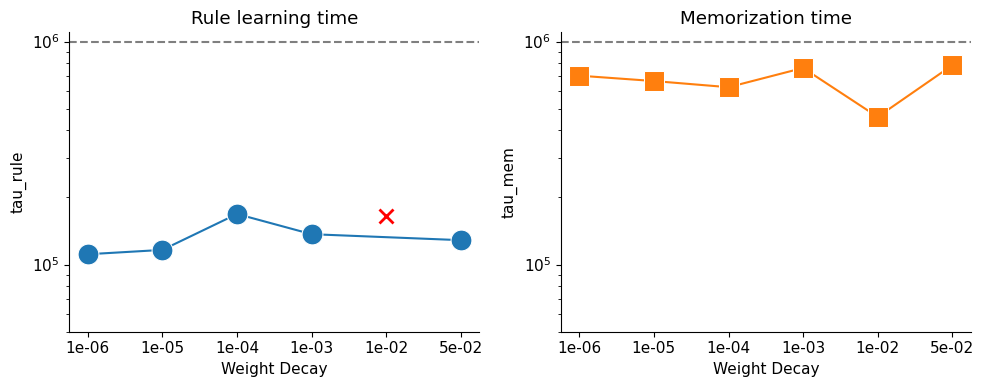

In [ ]:


tau_rule_list = []
tau_mem_list = []
wd_list = []
for expname in wd_exps:
    tb_traces = load_eval_dataframe(expname, SAVEROOT)
    args = load_args(expname, SAVEROOT)
    wd = args.get("weight_decay")
    # Compute tau_rule and tau_mem; if trace missing, mark as nan
    tau_rule = first_sustained_crossing(tb_traces['step'], tb_traces['valid_acc'], 0.90)
    tau_mem  = first_sustained_crossing(tb_traces['step'], tb_traces['mem_ratio'], 0.1)
    wd_list.append(wd)
    tau_rule_list.append(tau_rule)# if ~np.isnan(tau_rule) else 0)
    tau_mem_list.append(tau_mem)# if ~np.isnan(tau_mem) else 0)
df_wd_list = pd.DataFrame({'wd': wd_list, 'tau_rule': tau_rule_list, 'tau_mem': tau_mem_list})

import matplotlib.pyplot as plt

# Assume df_lr_list exists from above with columns 'lr', 'tau_rule', 'tau_mem'
# Plot: categorical x = 'lr', bar height = 'tau_rule' and 'tau_mem'
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
# Cast lr to string for categorical axis
x_labels = [f"{lr:.0e}" for lr in df_wd_list['wd']]
sns.lineplot(x=x_labels, y=df_wd_list['tau_rule'], ax=axs[0], marker='o', markersize=15, color='tab:blue')
sns.lineplot(x=x_labels, y=df_wd_list['tau_mem'], ax=axs[1], marker='s', markersize=15, color='tab:orange')
# Add red crosses where value is 0 or nan
mark_cross_on_ax(axs[0], x_labels, df_wd_list['tau_rule'])
mark_cross_on_ax(axs[1], x_labels, df_wd_list['tau_mem'])

axs[0].set_title('Rule learning time')
axs[1].set_title('Memorization time')
axs[0].set_xlabel('Weight Decay')
axs[1].set_xlabel('Weight Decay')
axs[0].set_ylabel('tau_rule')
axs[1].set_ylabel('tau_mem')
for ax in axs:
    ax.set_yscale('log')
    ax.set_ylim(5e4, 1.1e6)
    ax.axhline(1e6, color='k', linestyle='--', alpha=0.5)
# --- Color the xlabel 1E-04 in red (main exp) ---
# # Find which xtick label is 1e-4 (in scientific: 1E-04, which is f"{1e-4:.0e}" == '1e-04' or '1E-04')
# for ax in axs:
#     for label in ax.get_xticklabels():
#         # Label text can be upper or lower case; handle both
#         if label.get_text().lower() == '1e-04' or label.get_text().upper() == '1E-04':
#             label.set_color('red')
#         # Also, sometimes matplotlib may use e-4 for small values, check for both (in case)
#         if label.get_text() in ['1e-04', '1E-04']:
#             label.set_color('red')
plt.tight_layout()
saveallforms(FIGDIR, 'DiT_mini_G6_tau_rule_mem_wd_sweep', fig)
plt.show()

### GPT

In [111]:
df = pd.read_pickle('/n/home12/binxuwang/Github/DiffusionAttnConsistency/outputs/parity_onset_table.pkl')
df = pd.read_pickle('/n/home12/binxuwang/Github/DiffusionAttnConsistency/outputs/generalized_onset_table.pkl')
# '../outputs/generalized_onset_table.csv'
df = df.assign(model_str=df['model_arch'] + '-' + df['model_size'])
print(df.shape)
df.head(5)
# let the rule onset time to be before the mem onset time
df["rule_onset_acc90_innov"] = df["rule_onset_acc90"]
for i in range(len(df)):
    if ~pd.isna(df.loc[i, "rule_onset_acc90"]) and ~pd.isna(df.loc[i, "mem_onset_stat"]):
        if df.loc[i, "rule_onset_acc90"] > df.loc[i, "mem_onset_stat"]:
            df.loc[i, "rule_onset_acc90_innov"] = pd.NA


(128, 36)


In [92]:
df.query('model_arch == "GPT" and exp_name.str.contains("lr")')#.head(5)

,exp_name,task_type,model_arch,model_size,rep,N,n_size,D,K,K_list,...,block_onset_90,mem_onset_mem10,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,novel_onset_01,novel_onset_05,novel_onset_09,model_str
98,GPT_mini_parity_N4096_D36_G6_even_lr1e3,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GPT-mini
99,GPT_mini_parity_N4096_D36_G6_even_lr1e4,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,15888.0,15888.0,16144.0,16656.0,15888.0,1828.0,2260.0,2916.0,GPT-mini
100,GPT_mini_parity_N4096_D36_G6_even_lr1e5,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,37648.0,40464.0,43536.0,47376.0,37648.0,9480.0,10512.0,13328.0,GPT-mini
101,GPT_mini_parity_N4096_D36_G6_even_lr3e3,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GPT-mini
102,GPT_mini_parity_N4096_D36_G6_even_lr3e4,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,5384.0,5512.0,5640.0,6024.0,5384.0,4836.0,NaN,NaN,GPT-mini
103,GPT_mini_parity_N4096_D36_G6_even_lr3e5,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,12048.0,12816.0,14352.0,15632.0,12048.0,3556.0,8072.0,8328.0,GPT-mini


In [93]:
df.query('model_arch == "GPT" and exp_name.str.contains("wd")')

,exp_name,task_type,model_arch,model_size,rep,N,n_size,D,K,K_list,...,block_onset_90,mem_onset_mem10,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,novel_onset_01,novel_onset_05,novel_onset_09,model_str
104,GPT_mini_parity_N4096_D36_G6_even_wd0,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,5640.0,5896.0,6280.0,6792.0,5640.0,4484.0,NaN,NaN,GPT-mini
105,GPT_mini_parity_N4096_D36_G6_even_wd1e0,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,30224.0,36368.0,51024.0,67920.0,30224.0,2244.0,NaN,NaN,GPT-mini
106,GPT_mini_parity_N4096_D36_G6_even_wd1e1,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,7304.0,7816.0,8328.0,8968.0,7304.0,1844.0,NaN,NaN,GPT-mini
107,GPT_mini_parity_N4096_D36_G6_even_wd1e2,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,8072.0,8584.0,8968.0,9608.0,8072.0,1908.0,4996.0,NaN,GPT-mini
108,GPT_mini_parity_N4096_D36_G6_even_wd1e3,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,8456.0,8968.0,9608.0,10256.0,8456.0,2484.0,6024.0,NaN,GPT-mini
109,GPT_mini_parity_N4096_D36_G6_even_wd3e1,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,21008.0,22032.0,23056.0,24080.0,21008.0,1492.0,1732.0,2692.0,GPT-mini
110,GPT_mini_parity_N4096_D36_G6_even_wd5e2,parity,GPT,mini,1,4096,NaN,36.0,NaN,,...,NaN,7176.0,7560.0,7944.0,8456.0,7176.0,2116.0,5768.0,NaN,GPT-mini


In [95]:
df.columns

Index(['exp_name', 'task_type', 'model_arch', 'model_size', 'rep', 'N',
       'n_size', 'D', 'K', 'K_list', 'G', 'encoding', 'n_layer', 'n_embd',
       'n_head', 'lr', 'wd', 'nsteps', 'support_size', 'stat_mem_frac',
       'stat_mem_thresh', 'rule_onset_acc85', 'rule_onset_acc90',
       'rule_onset_acc95', 'row_onset_90', 'col_onset_90', 'block_onset_90',
       'mem_onset_mem10', 'mem_onset_mem20', 'mem_onset_mem35',
       'mem_onset_mem50', 'mem_onset_stat', 'novel_onset_01', 'novel_onset_05',
       'novel_onset_09', 'model_str'],
      dtype='object')

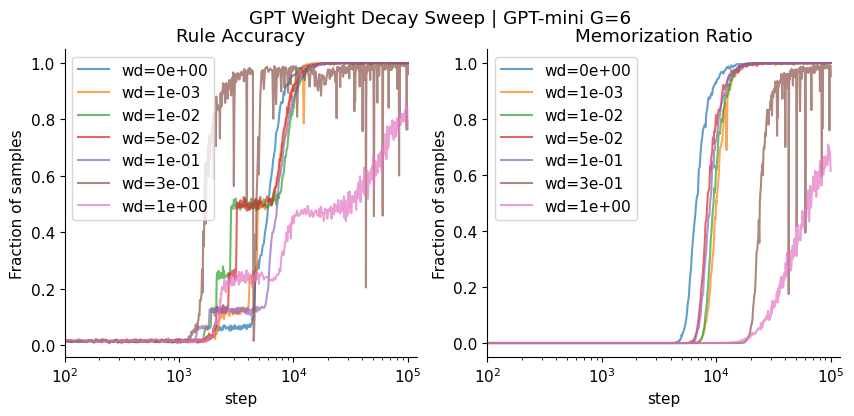

In [107]:
GPT_wd_sweep = df.query('model_arch == "GPT" and exp_name.str.contains("wd")').copy()
GPT_wd_sweep.sort_values('wd', inplace=True)
figh, axs = plt.subplots(1, 2, figsize=(10, 4))
for expname in GPT_wd_sweep.exp_name:
    tb_traces = load_eval_dataframe(expname, SAVEROOT)
    args = load_args(expname, SAVEROOT)
    wd = args.get("weight_decay")
    sns.lineplot(data=tb_traces, x='step', y='valid_acc', label=f'wd={wd:.0e}', ax=axs[0], alpha=0.7)  
    sns.lineplot(data=tb_traces, x='step', y='mem_ratio', label=f'wd={wd:.0e}', ax=axs[1], alpha=0.7)  
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].set_title('Rule Accuracy')
axs[1].set_title('Memorization Ratio')
axs[0].set_ylabel('Fraction of samples')
axs[1].set_ylabel('Fraction of samples')
axs[0].legend()
axs[0].set_xlim(1E2, 1.2e5)
axs[1].set_xlim(1E2, 1.2e5)
# axs[1].legend()
plt.suptitle('GPT Weight Decay Sweep | GPT-mini G=6')
saveallforms(FIGDIR, 'GPT_mini_G6_learning_curves_wd_sweep', figh)
plt.show()

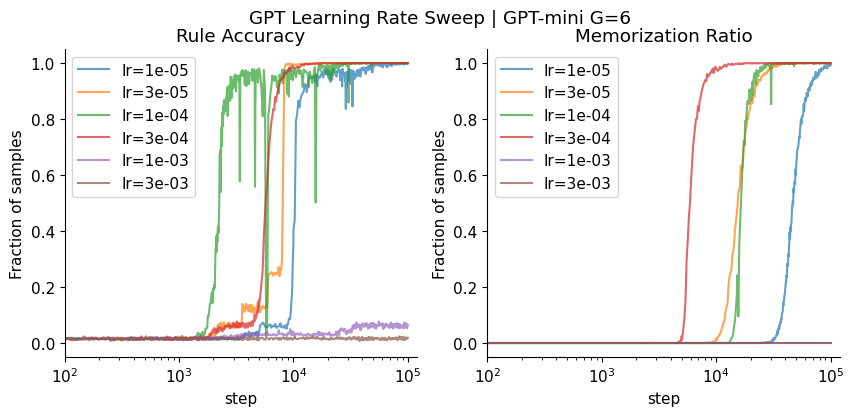

In [108]:
GPT_lr_sweep = df.query('model_arch == "GPT" and exp_name.str.contains("lr")').copy()
GPT_lr_sweep.sort_values('lr', inplace=True)
figh, axs = plt.subplots(1, 2, figsize=(10, 4))
for expname in GPT_lr_sweep.exp_name:
    tb_traces = load_eval_dataframe(expname, SAVEROOT)
    args = load_args(expname, SAVEROOT)
    lr = args.get("lr")
    sns.lineplot(data=tb_traces, x='step', y='valid_acc', label=f'lr={lr:.0e}', ax=axs[0], alpha=0.7)  
    sns.lineplot(data=tb_traces, x='step', y='mem_ratio', label=f'lr={lr:.0e}', ax=axs[1], alpha=0.7)  
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].set_title('Rule Accuracy')
axs[1].set_title('Memorization Ratio')
axs[0].set_ylabel('Fraction of samples')
axs[1].set_ylabel('Fraction of samples')
axs[0].legend()
axs[0].set_xlim(1E2, 1.2e5)
axs[1].set_xlim(1E2, 1.2e5)
# axs[1].legend()
plt.suptitle('GPT Learning Rate Sweep | GPT-mini G=6')
saveallforms(FIGDIR, 'GPT_mini_G6_learning_curves_lr_sweep', figh)
plt.show()

In [89]:
def color_xtick_label(axs, label_to_color="1e-04", color="red"):
    """
    Colors the x-tick label matching `label_to_color` in each axis in axs.
    Accepts axs as a single axis or iterable of axes.
    Handles different casing and e-notation.
    """
    if not isinstance(axs, (list, tuple, np.ndarray)):
        axs = [axs]
    label_to_color_variants = [label_to_color, label_to_color.upper(), label_to_color.lower()]
    for ax in axs:
        for label in ax.get_xticklabels():
            text = label.get_text()
            # Accept a variety of scientific representations (e.g., 1e-04, 1E-04)
            if text in label_to_color_variants:
                label.set_color(color)


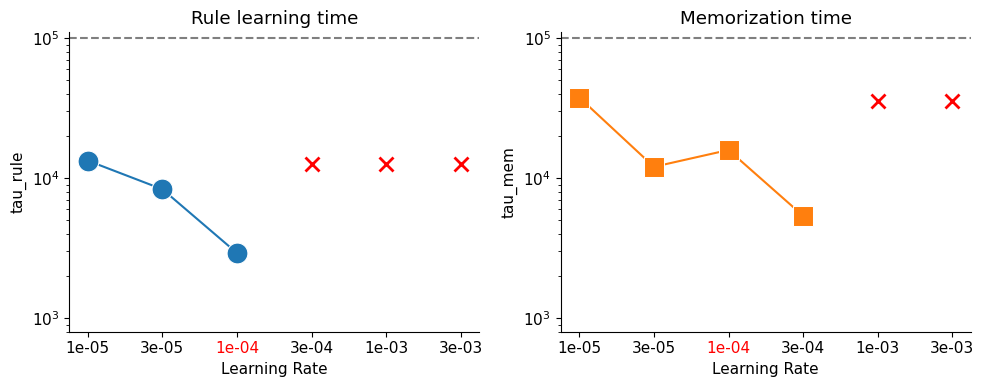

In [116]:
GPT_lr_sweep = df.query('model_arch == "GPT" and exp_name.str.contains("lr")').copy()
GPT_lr_sweep.sort_values('lr', inplace=True)
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
# Cast lr to string for categorical axis
x_labels = [f"{lr:.0e}" for lr in GPT_lr_sweep['lr']]
sns.lineplot(x=x_labels, y=GPT_lr_sweep['rule_onset_acc90_innov'], ax=axs[0], marker='o', markersize=15, color='tab:blue')
sns.lineplot(x=x_labels, y=GPT_lr_sweep['mem_onset_stat'], ax=axs[1], marker='s', markersize=15, color='tab:orange')
# Add red crosses where value is 0 or nan
mark_cross_on_ax(axs[0], x_labels, GPT_lr_sweep['rule_onset_acc90_innov'])
mark_cross_on_ax(axs[1], x_labels, GPT_lr_sweep['mem_onset_stat'])

axs[0].set_title('Rule learning time')
axs[1].set_title('Memorization time')
axs[0].set_xlabel('Learning Rate')
axs[1].set_xlabel('Learning Rate')
axs[0].set_ylabel('tau_rule')
axs[1].set_ylabel('tau_mem')
for ax in axs:
    ax.set_yscale('log')
    ax.set_ylim(8e2, 1.1e5)
    ax.axhline(1e5, color='k', linestyle='--', alpha=0.5)
# --- Color the xlabel 1E-04 in red (main exp) ---
color_xtick_label(axs, label_to_color="1e-04", color="red")
plt.tight_layout()
saveallforms(FIGDIR, 'GPT_mini_G6_tau_rule_mem_lr_sweep', fig)
plt.show()

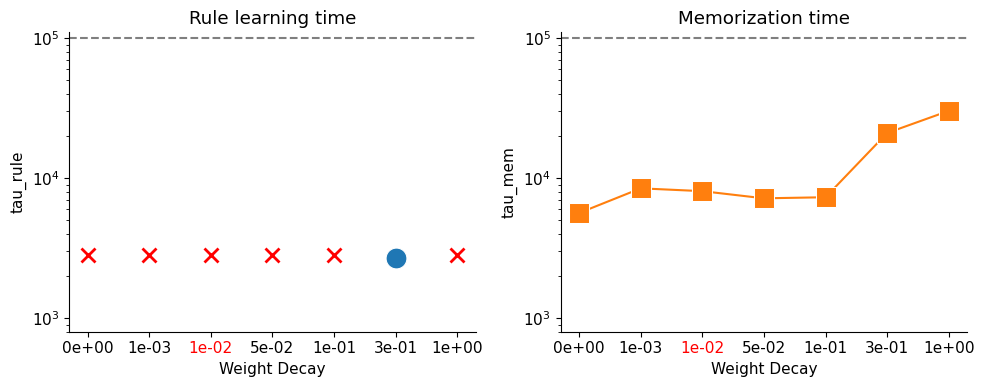

In [117]:
GPT_wd_sweep = df.query('model_arch == "GPT" and exp_name.str.contains("wd")').copy()
GPT_wd_sweep.sort_values('wd', inplace=True)
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
# Cast lr to string for categorical axis
x_labels = [f"{wd:.0e}" for wd in GPT_wd_sweep['wd']]
sns.lineplot(x=x_labels, y=GPT_wd_sweep['rule_onset_acc90_innov'], ax=axs[0], marker='o', markersize=15, color='tab:blue')
sns.lineplot(x=x_labels, y=GPT_wd_sweep['mem_onset_stat'], ax=axs[1], marker='s', markersize=15, color='tab:orange')
# Add red crosses where value is 0 or nan
mark_cross_on_ax(axs[0], x_labels, GPT_wd_sweep['rule_onset_acc90_innov'])
mark_cross_on_ax(axs[1], x_labels, GPT_wd_sweep['mem_onset_stat'])

axs[0].set_title('Rule learning time')
axs[1].set_title('Memorization time')
axs[0].set_xlabel('Weight Decay')
axs[1].set_xlabel('Weight Decay')
axs[0].set_ylabel('tau_rule')
axs[1].set_ylabel('tau_mem')
for ax in axs:
    ax.set_yscale('log')
    ax.set_ylim(8e2, 1.1e5)
    ax.axhline(1e5, color='k', linestyle='--', alpha=0.5)
# --- Color the xlabel 1E-04 in red (main exp) ---
color_xtick_label(axs, label_to_color="1e-02", color="red")
plt.tight_layout()
saveallforms(FIGDIR, 'GPT_mini_G6_tau_rule_mem_wd_sweep', fig)
plt.show()

In [3]:
# ── Data loading helpers ──────────────────────────────────────────────────────
def load_tb(exp_name):
    tbdir = os.path.join(SAVEROOT, exp_name, 'tensorboard')
    ea = EventAccumulator(tbdir, size_guidance={'scalars': 0})
    ea.Reload()
    out = {}
    for tag, label in TAGS:
        if tag in ea.Tags()['scalars']:
            evts = ea.Scalars(tag)
            out[label] = (np.array([e.step for e in evts]),
                          np.array([e.value for e in evts]))
    return out

def smooth(y, k=15):
    if len(y) < k: return y
    return np.convolve(y, np.ones(k)/k, mode='same')

def first_above(steps, vals, thresh):
    idx = np.where(vals >= thresh)[0]
    return int(steps[idx[0]]) if len(idx) > 0 else -1

def compute_metrics(exp_name):
    steps_acc, vals_acc = (lambda d: d.get('Sample Accuracy', (None,None)))(load_tb(exp_name))
    # reload once for mem
    d = load_tb(exp_name)
    steps_acc, vals_acc = d.get('Sample Accuracy', (None, None))
    steps_mem, vals_mem = d.get('Sample Mem Ratio', (None, None))
    m = {}
    if vals_acc is not None:
        m['peak_acc']   = float(vals_acc.max())
        m['end_acc']    = float(vals_acc[-5:].mean())
        m['step_acc80'] = first_above(steps_acc, vals_acc, 0.80)
    else:
        m['peak_acc'] = m['end_acc'] = m['step_acc80'] = float('nan')
    if vals_mem is not None:
        m['step_mem1pct'] = first_above(steps_mem, vals_mem, 0.01)
        m['end_mem']      = float(vals_mem[-5:].mean())
    else:
        m['step_mem1pct'] = -1
        m['end_mem']      = float('nan')
    return m

print('Loading LR sweep data...')
lr_data    = [load_tb(e) for e in lr_exps]
lr_metrics = [compute_metrics(e) for e in lr_exps]
print('Loading WD sweep data...')
wd_data    = [load_tb(e) for e in wd_exps]
wd_metrics = [compute_metrics(e) for e in wd_exps]
print('Done.')

Loading LR sweep data...


Loading WD sweep data...


Done.


## 1. Training traces — LR sweep

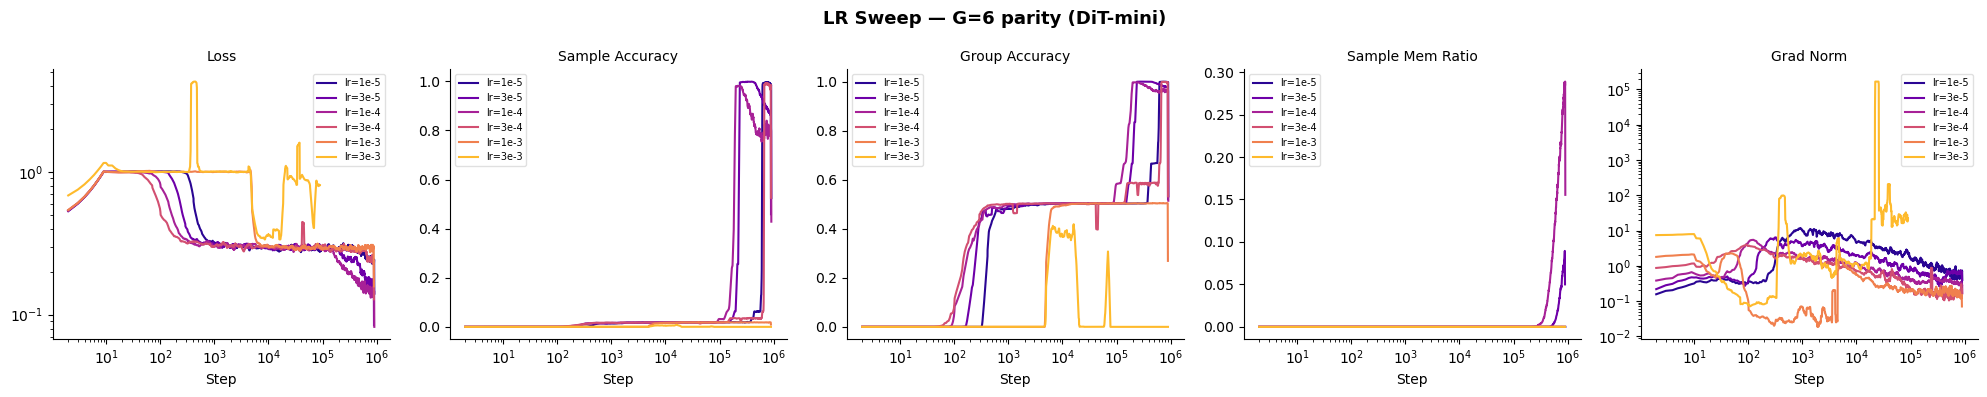

In [4]:
def plot_traces(data_list, labels, colors, title, fname=None):
    n = len(TAGS)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (_, label) in zip(axes, TAGS):
        for d, lbl, col in zip(data_list, labels, colors):
            if label not in d: continue
            steps, vals = d[label]
            ax.plot(steps+1, smooth(vals), color=col, lw=1.5, label=lbl)
        ax.set_xscale('log')
        if label in ('Loss', 'Grad Norm'): ax.set_yscale('log')
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Step')
        ax.legend(fontsize=7, framealpha=0.6)
    plt.tight_layout()
    if fname:
        for ext in ['png','pdf']:
            fig.savefig(os.path.join(FIGDIR, f'{fname}.{ext}'), dpi=150, bbox_inches='tight')
    plt.show()

plot_traces(lr_data, lr_labels, lr_colors,
            'LR Sweep — G=6 parity (DiT-mini)',
            'sweep_lr_G6_parity')

## 2. Training traces — WD sweep

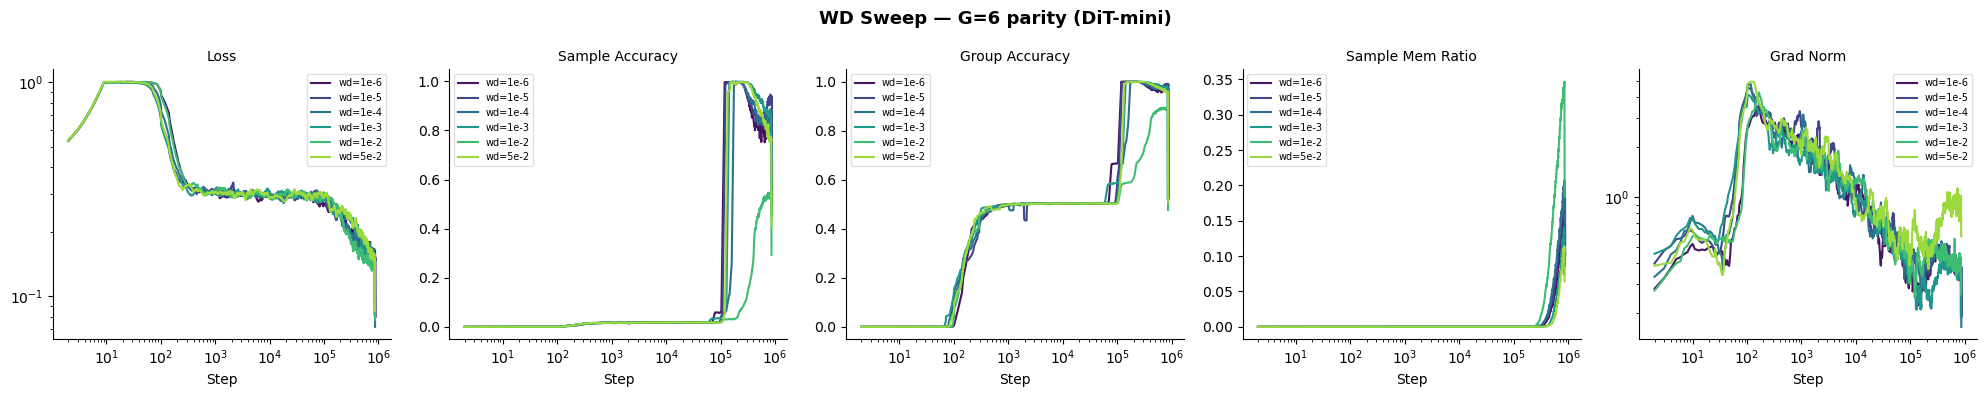

In [5]:
plot_traces(wd_data, wd_labels, wd_colors,
            'WD Sweep — G=6 parity (DiT-mini)',
            'sweep_wd_G6_parity')

## 3. Summary bars — LR sweep

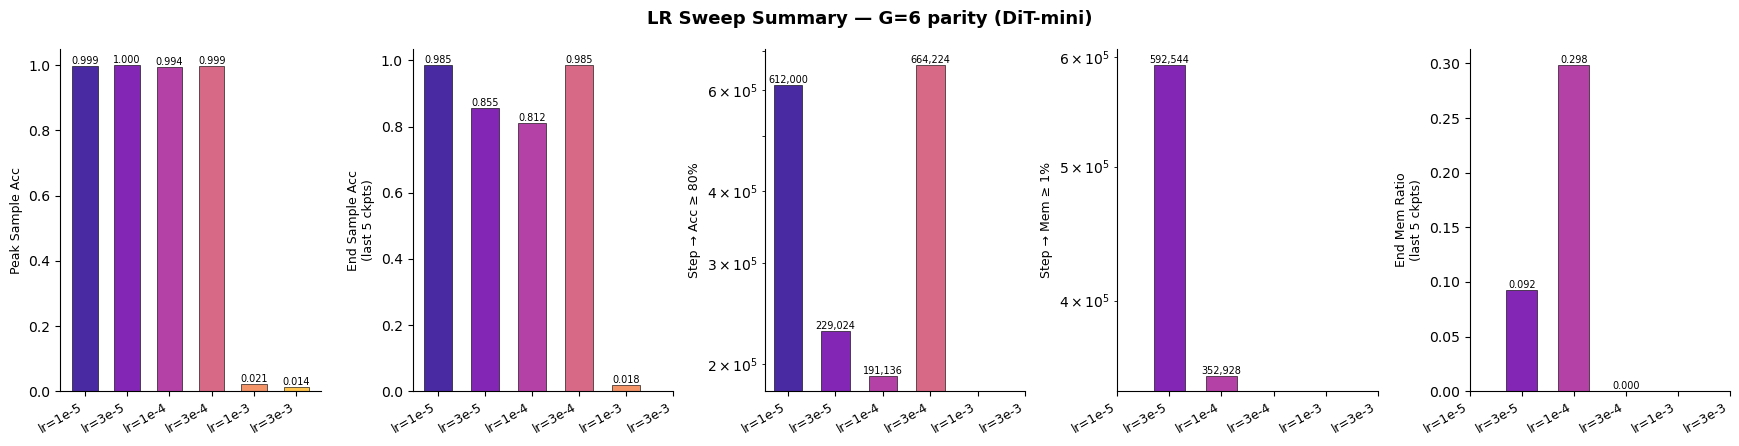

In [6]:
BAR_PANELS = [
    ('peak_acc',     'Peak Sample Acc',                '.3f', False),
    ('end_acc',      'End Sample Acc\n(last 5 ckpts)', '.3f', False),
    ('step_acc80',   'Step → Acc ≥ 80%',               'step', True),
    ('step_mem1pct', 'Step → Mem ≥ 1%',                'step', True),
    ('end_mem',      'End Mem Ratio\n(last 5 ckpts)',   '.3f', False),
]

def bar_panel(ax, labels, values, ylabel, colors, fmt='.2f', log_y=False):
    x = np.arange(len(labels))
    bars = ax.bar(x, values, color=colors, width=0.6, alpha=0.85,
                  edgecolor='k', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    if log_y: ax.set_yscale('log')
    for bar, v in zip(bars, values):
        if np.isnan(v) or v <= 0: continue
        txt = f'{int(v):,}' if fmt == 'step' else f'{v:{fmt}}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                txt, ha='center', va='bottom', fontsize=7)

def plot_bars(metrics, labels, colors, title, fname=None):
    fig, axes = plt.subplots(1, len(BAR_PANELS), figsize=(3.5*len(BAR_PANELS), 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (key, ylabel, fmt, log_y) in zip(axes, BAR_PANELS):
        vals = [m[key] for m in metrics]
        vals_plot = [v if (not isinstance(v, float) or not np.isnan(v)) and v > 0
                     else np.nan for v in vals]
        bar_panel(ax, labels, vals_plot, ylabel, colors, fmt=fmt, log_y=log_y)
    plt.tight_layout()
    if fname:
        for ext in ['png','pdf']:
            fig.savefig(os.path.join(FIGDIR, f'{fname}.{ext}'), dpi=150, bbox_inches='tight')
    plt.show()

plot_bars(lr_metrics, lr_labels, lr_colors,
          'LR Sweep Summary — G=6 parity (DiT-mini)',
          'sweep_lr_G6_parity_bars')

## 4. Summary bars — WD sweep

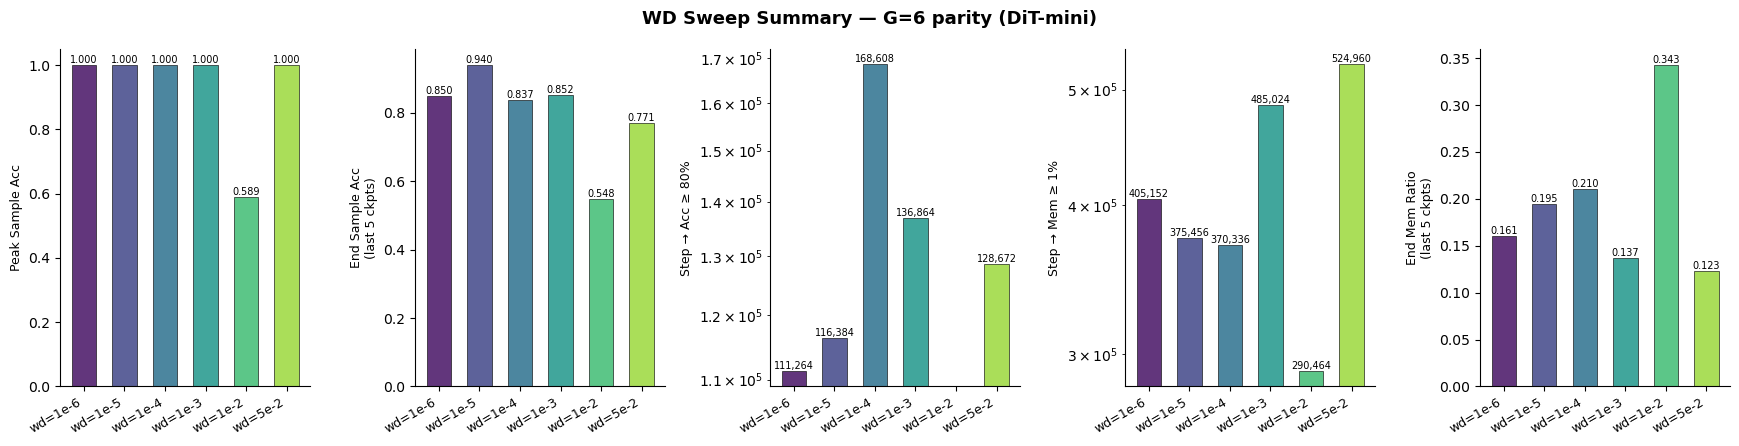

In [7]:
plot_bars(wd_metrics, wd_labels, wd_colors,
          'WD Sweep Summary — G=6 parity (DiT-mini)',
          'sweep_wd_G6_parity_bars')

## 5. Combined: traces + bars side-by-side per sweep

/tmp/ipykernel_1391626/2148457415.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


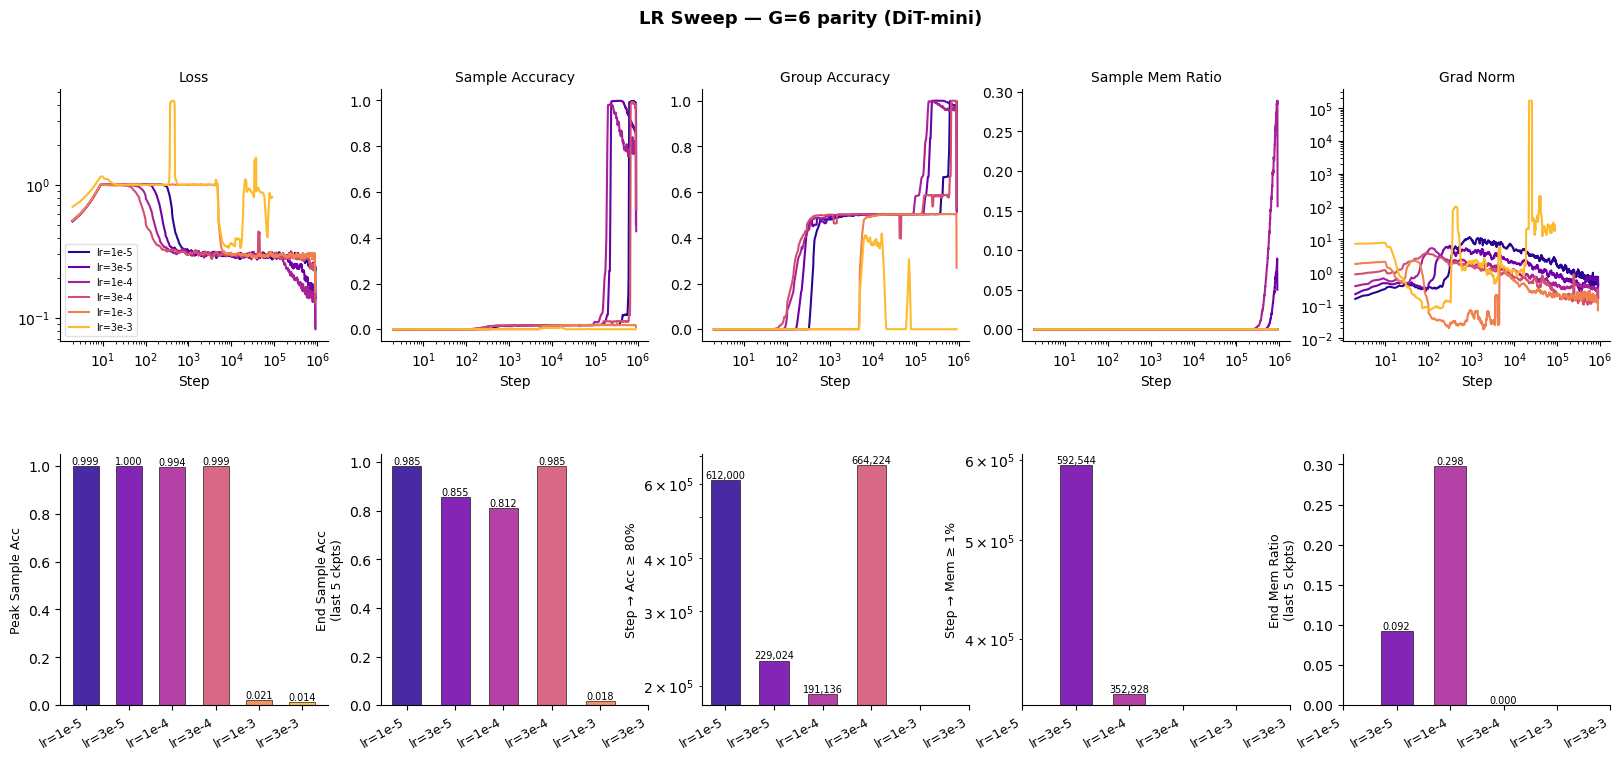

Saved sweep_lr_G6_parity_combined


/tmp/ipykernel_1391626/2148457415.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


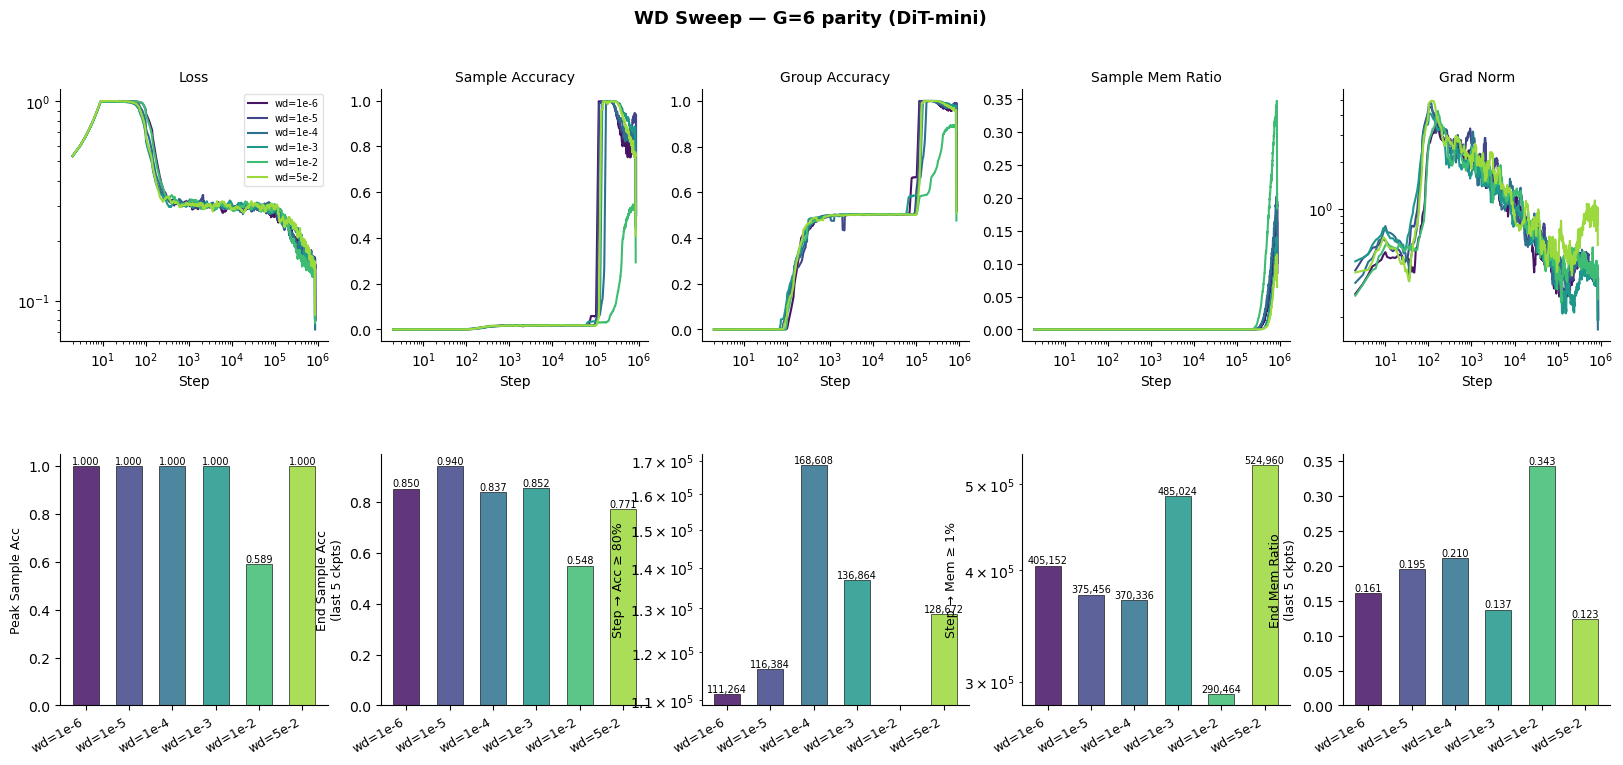

Saved sweep_wd_G6_parity_combined


In [8]:
# Convenience: regenerate both sweeps as a single tall figure
for sweep_name, data_list, metrics, labels, colors, fname in [
    ('LR', lr_data, lr_metrics, lr_labels, lr_colors, 'sweep_lr_G6_parity_combined'),
    ('WD', wd_data, wd_metrics, wd_labels, wd_colors, 'sweep_wd_G6_parity_combined'),
]:
    n_trace = len(TAGS)
    n_bar   = len(BAR_PANELS)
    fig, axes = plt.subplots(2, max(n_trace, n_bar),
                              figsize=(4*max(n_trace,n_bar), 8),
                              gridspec_kw={'hspace': 0.45})
    fig.suptitle(f'{sweep_name} Sweep — G=6 parity (DiT-mini)', fontsize=13, fontweight='bold')

    # Row 0: traces
    for i, (ax, (_, label)) in enumerate(zip(axes[0], TAGS)):
        for d, lbl, col in zip(data_list, labels, colors):
            if label not in d: continue
            steps, vals = d[label]
            ax.plot(steps+1, smooth(vals), color=col, lw=1.5, label=lbl)
        ax.set_xscale('log')
        if label in ('Loss', 'Grad Norm'): ax.set_yscale('log')
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Step')
        if i == 0: ax.legend(fontsize=7, framealpha=0.6)
    for ax in axes[0, n_trace:]: ax.set_visible(False)

    # Row 1: bars
    for i, (ax, (key, ylabel, fmt, log_y)) in enumerate(zip(axes[1], BAR_PANELS)):
        vals = [m[key] for m in metrics]
        vals_plot = [v if (not isinstance(v, float) or not np.isnan(v)) and v > 0
                     else np.nan for v in vals]
        bar_panel(ax, labels, vals_plot, ylabel, colors, fmt=fmt, log_y=log_y)
    for ax in axes[1, n_bar:]: ax.set_visible(False)

    plt.tight_layout()
    for ext in ['png','pdf']:
        fig.savefig(os.path.join(FIGDIR, f'{fname}.{ext}'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')